In [1]:
%pip install -r requirements.txt 

  Using cached wfdb-3.1.0-py3-none-any.whl (117 kB)
  Using cached mne-0.20.7-py3-none-any.whl (6.6 MB)
  Using cached cycler-0.10.0-py2.py3-none-any.whl (6.5 kB)
  Using cached pytz-2019.3-py2.py3-none-any.whl (509 kB)
  Using cached matplotlib-3.2.1.tar.gz (40.3 MB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached sklearn-0.0.tar.gz (1.1 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached requests-2.23.0-py2.py3-none-any.whl (58 kB)
  Using cached pandas-1.0.3.tar.gz (5.0 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × pip subprocess to install build dependencies did not run successfully.
  │ exit code: 1
  ╰─> [598 lines of output]
      Ignoring numpy: markers 'python_version == "3.6" and platform_system != "AIX"' don't match your environment
      Ignoring numpy: markers 'python_version == "3.6" and platform_system == "AIX"' don't match your environment
      Ignoring numpy: markers 'python_version >= "3.7" and platform_system == "AIX"' don't match your environment
        Using cached setuptools-80.9.0-py3-none-any.whl (1.2 MB)
        Using cached wheel-0.45.1-py3-none-any.whl (72 kB)
        Using cached cython-3.1.3-cp310-cp310-win_amd64.whl (2.7 MB)
        Using cached numpy-1.14.5.zip (4.9 MB)
        Preparing metadata (setup.py): started
        Preparing metadata (setup.py): finished with status 'done'
        error: subprocess-exited-with-error
      
        Ã— python setup.py bdist_wheel did not run successfully.
        â”‚ exit code: 1
  

In [11]:
st_petersburg_incart_12lead_arrhythmia_database_path = r'data/china-12lead-ecg-challenge-database'
ptbxl_electrocardiography_database_path = r'data/ptbxl_electrocardiography_database'
ptb_diagnostic_ecg_database_path = r'data/ptb_diagnostic_ecg_database'
china_physiological_signal_challenge_in_2018_path = r'data/china_physiological_signal_challenge_2018'
china_12lead_ecg_challenge_database_path = r'data/china_12lead_ecg_challenge_database'
physionet_snomed_mappings_path = r'data/physionet_snomed_mappings'
physionet_challenge_models_path = r'datas/physionet_challenge_models'
georgia_12lead_ecg_challenge_database_path = r'data/georgia_12lead_ecg_challenge_database'
physionet_challenge_utility_script_path = r'notebooks/physionet_challenge_utility_script_patched_v2.py'

In [3]:
import sys
import os

# Add the directory to sys.path
sys.path.append(os.path.dirname(physionet_challenge_utility_script_path))

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ecg_plot

import tensorflow as tf
import keras

from scipy import optimize
from matplotlib.pyplot import figure

from keras.utils import plot_model
from keras.preprocessing.sequence import pad_sequences

In [5]:
%load_ext autoreload
%autoreload 2

import sys
import os

# Add the directory containing the utility script to sys.path
sys.path.append(os.path.dirname(physionet_challenge_utility_script_path))

import physionet_challenge_utility_script_patched_v2 as pc

In [6]:
import ecg_plot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow_addons as tfa
import tensorflow as tf
from tensorflow import keras
from keras.utils import plot_model
from keras.preprocessing.sequence import pad_sequences

C:\Users\nares\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\tensorflow_addons\utils\tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(


In [7]:
import os
os.chdir(r"C:\Users\nares\Documents\cvd-early-detection-ecg-uhull")

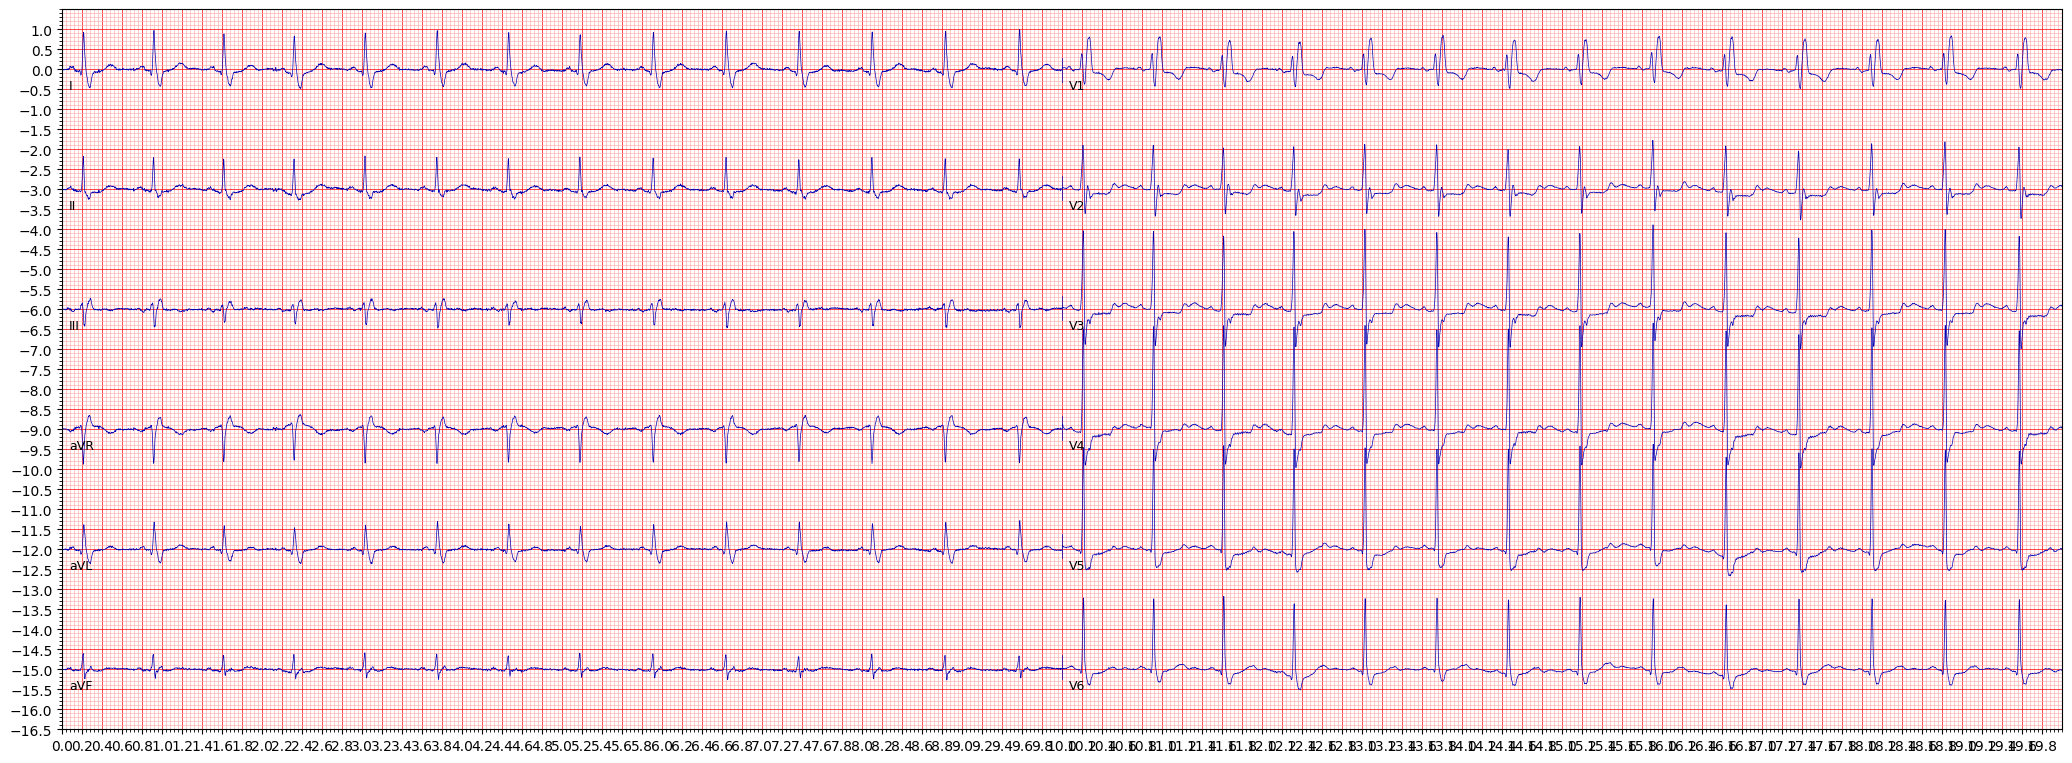

In [8]:
def plot_ecg(path):
    ecg_data = pc.load_challenge_data(path)
    ecg_plot.plot(ecg_data[0]/1000, sample_rate=500, title='')
    ecg_plot.show()

plot_ecg("data/china-12lead-ecg-challenge-database/Training_2/Q0948.mat") 

In [9]:
ecg_data = pc.load_challenge_data("data/china-12lead-ecg-challenge-database/Training_2/Q0948.mat")
ecg_data[0].shape

(12, 5000)

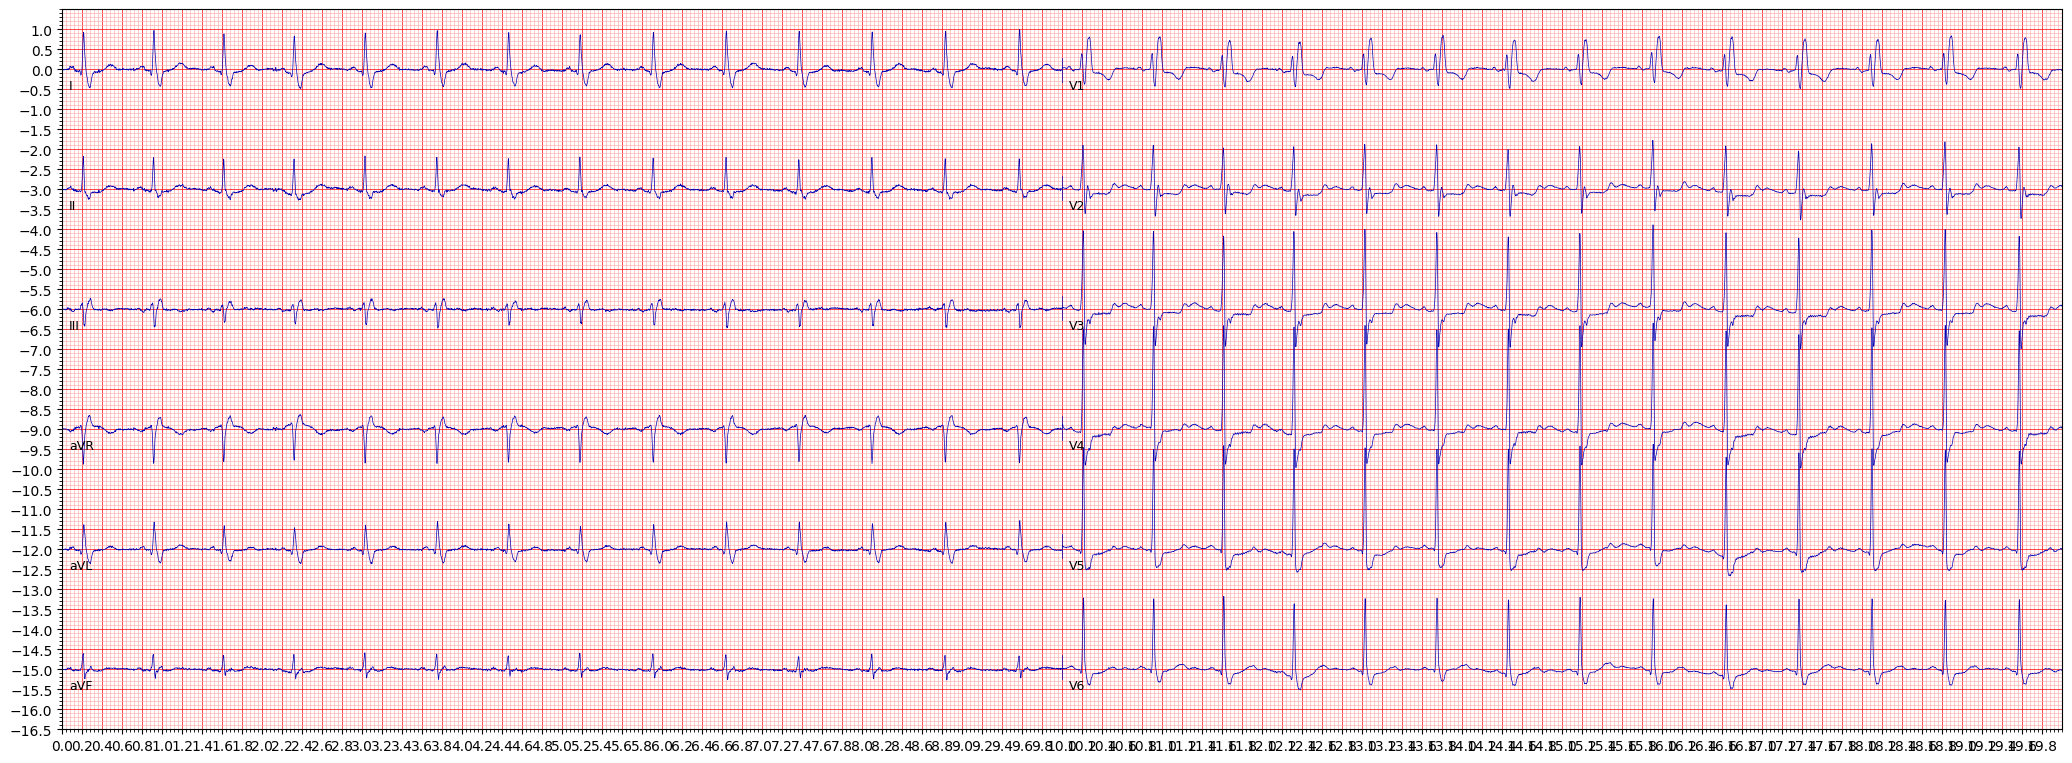

In [10]:
plot_ecg("data/china-12lead-ecg-challenge-database/Training_2/Q0948.mat")

### Methods


#### Data
The training data in this study contains 43,101 Electrocariographic recordings from 4 different sources. 
1. Southeast University, China, including the data from the China Physiological Signal Challenge 2018 (2 datasets from this source)
2. St. Petersburg Institute of Cardiological Technics, St. Petersburg, Russia.
3. The Physikalisch Technische Bundesanstalt, Brunswick, Germany. (2 datasets from this source)
4. Georgia 12-Lead ECG Challenge Database, Emory University, Atlanta, Georgia, USA.

The data is given in the form of native Python waveform-database-format [WFDB](https://wfdb.readthedocs.io/en/latest/). The dataset contains two file types:


1.   Header files (.hea)
2.   Signal files (.mat)

We have 43,101 Signal file with a corresponding header file. Each file are named with a patient number starting with ***A0001*** and goes all the way up to ***A6877***


//NARESH

We are building the total data hea./.mat files into  csv for faster runs.

In [14]:
from pathlib import Path
import pandas as pd
import re

SEX_RE = re.compile(r'(?i)#\s*sex\s*:\s*([A-Za-z?]+)')
AGE_RE = re.compile(r'(?i)#\s*age\s*:\s*([0-9]+|NaN|\?)')
DX_RE  = re.compile(r'(?i)#\s*dx\s*:\s*(.+)$')

def coerce_age(val):
    if val is None:
        return None
    v = val.strip()
    if v.lower() in {"nan", "?", ""}:
        return None
    try:
        return int(v)
    except ValueError:
        # sometimes age can be float-looking; try float -> int
        try:
            return int(float(v))
        except Exception:
            return None

def normalize_sex(val):
    if not val:
        return None
    v = val.strip().upper()
    # common encodings: M/F, Male/Female, U/?, etc.
    if v in {"M", "MALE"}:
        return "M"
    if v in {"F", "FEMALE"}:
        return "F"
    return None  # Unknown/other -> None (or return v if you want to keep)

def parse_header(hea_path: Path):
    sex = age = label = None
    signal_len = None
    fs = None

    with open(hea_path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    if not lines:
        return sex, age, label, signal_len, fs

    # First line usually like: "<recname> <n_sig> <fs> <nsamp> <date> <time>"
    first = lines[0].strip()
    parts = first.split()
    if len(parts) >= 4:
        # parts[2] = fs, parts[3] = number of samples
        try:
            fs = int(float(parts[2]))
        except Exception:
            fs = None
        try:
            signal_len = int(parts[3])
        except Exception:
            signal_len = None

    # Now scan ALL lines for comment metadata
    for raw in lines:
        ln = raw.strip()
        if not ln.startswith("#"):
            continue

        m = SEX_RE.search(ln)
        if m and sex is None:
            sex = normalize_sex(m.group(1))

        m = AGE_RE.search(ln)
        if m and age is None:
            age = coerce_age(m.group(1))

        m = DX_RE.search(ln)
        if m and label is None:
            # Keep the raw label string; or split to list if you prefer
            label = m.group(1).strip()

    return sex, age, label, signal_len, fs

def build_index(root):
    root = Path(root)
    rows = []
    for mat_path in sorted(root.rglob("*.mat")):
        hea_path = mat_path.with_suffix(".hea")
        if hea_path.exists():
            sex, age, label, siglen, fs = parse_header(hea_path)
            duration = (siglen / fs) if (siglen and fs) else None
            rows.append({
                "mat": str(mat_path),
                "hea": str(hea_path),
                "sex": sex,
                "age": age,
                "label": label,          # e.g., "164889003, 426783006"
                "signal_len": siglen,
                "fs": fs,
                "duration_sec": duration
            })
    return pd.DataFrame(rows)

# Build the index
df = build_index("data")
df.to_csv("ecg_index.csv", index=False)


#### From the figure under we can se that the signals varies, but most of the signals are around 5000 samples long

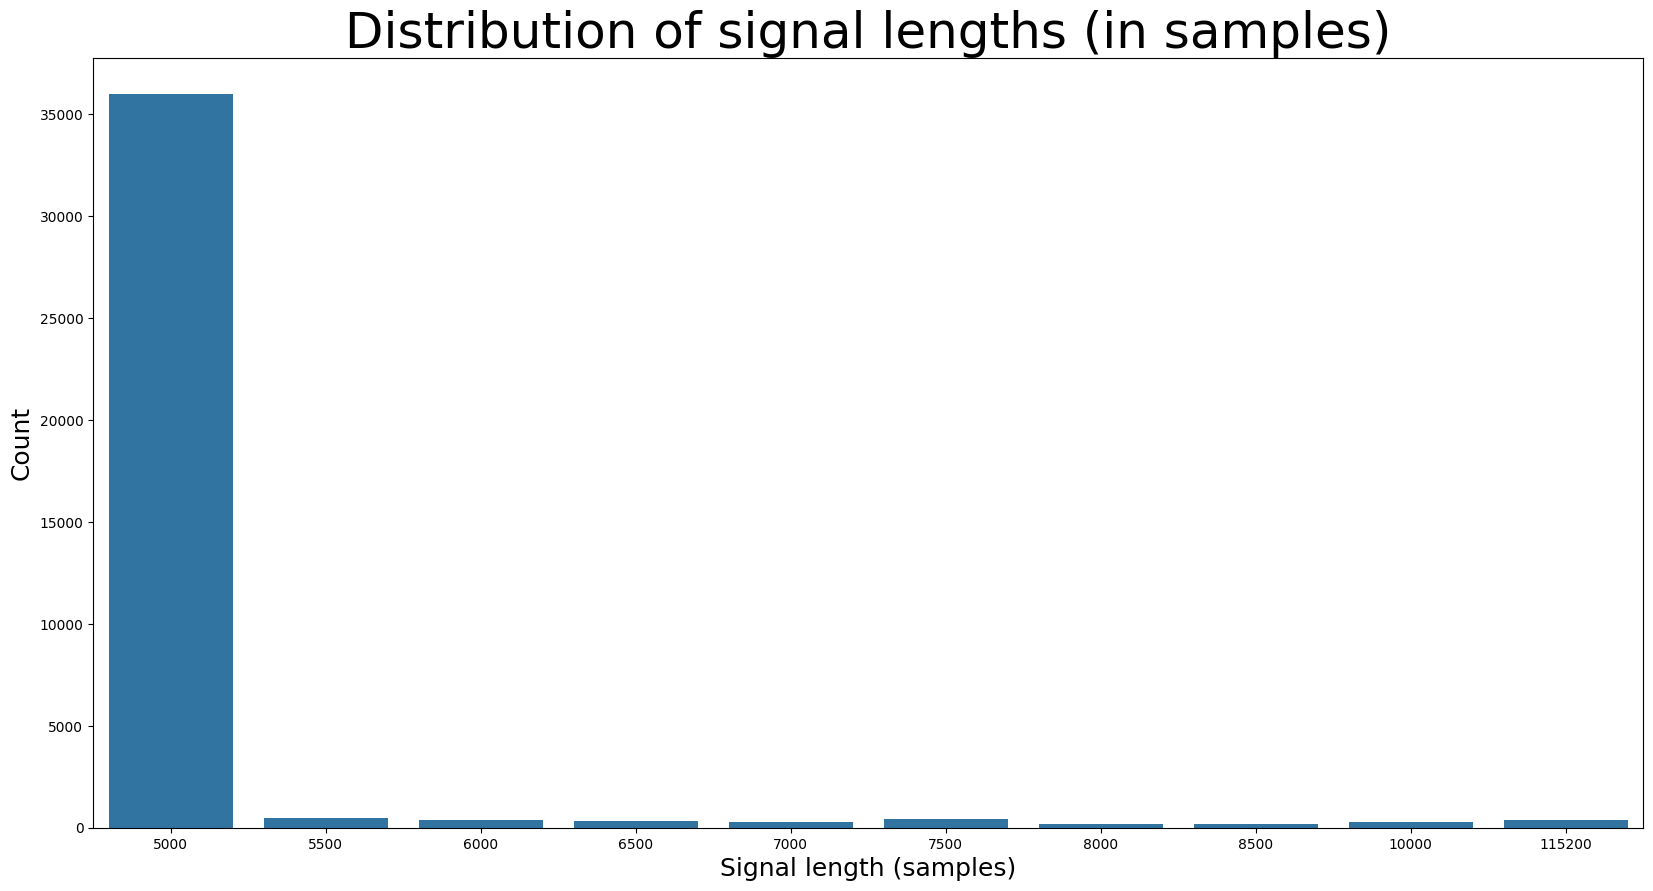

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load CSV
df = pd.read_csv("ecg_index.csv")

def plot_signal_lengths(df, title):
    signal_count = df["signal_len"].value_counts()

    plt.figure(figsize=(20, 10))
    plt.title(title, fontsize=36)
    sns.barplot(x=signal_count[:10].index, y=signal_count[:10].values)
    plt.xlabel("Signal length (samples)", fontsize=18)
    plt.ylabel("Count", fontsize=18)
    plt.show()

plot_signal_lengths(df, "Distribution of signal lengths (in samples)")


#### From the header file we have access to gender and age from each patient

In [20]:
def import_key_data_from_csv(csv_path="ecg_index.csv"):
    df = pd.read_csv(csv_path)
    gender = df["sex"].tolist()
    age = df["age"].tolist()
    labels = df["label"].tolist()
    ecg_filenames = df["mat"].tolist()
    return gender, age, labels, ecg_filenames

In [22]:
gender, age, labels, ecg_filenames = import_key_data_from_csv()

#### All diagnoses are encoded with SNOMED-CT codes. We need a CSV-file to decode them:

In [ ]:
SNOMED_scored = pd.read_csv("data/physionet-snomed-mappings/SNOMED_mappings_scored.csv", sep=";")
SNOMED_unscored = pd.read_csv("data/physionet-snomed-mappings/SNOMED_mappings_unscored.csv", sep=";")

df_labels = pc.make_undefined_class(labels, SNOMED_unscored)

In [25]:
print(df_labels)

                                                       0
0                              undefined class,427084000
1                                        undefined class
2                        undefined class,undefined class
3                        undefined class,undefined class
4                                        undefined class
...                                                  ...
43096    undefined class,undefined class,undefined class
43097  undefined class,undefined class,427084000,unde...
43098  undefined class,undefined class,426627000,6359...
43099  undefined class,427084000,undefined class,unde...
43100  undefined class,426627000,undefined class,unde...

[43101 rows x 1 columns]


#### To be able to feed the labels to a Neural Network we need to OneHot encode the labels

In [26]:
y , snomed_classes = pc.onehot_encode(df_labels)

The classes we will look at are encoded as SNOMED CT codes:
['10370003' '111975006' '164889003' '164890007' '164909002' '164917005'
 '164934002' '164947007' '17338001' '251146004' '270492004' '284470004'
 '39732003' '426177001' '426627000' '426783006' '427084000' '427172004'
 '427393009' '445118002' '47665007' '59118001' '59931005' '63593006'
 '698252002' '713426002' '713427006' 'undefined class']
classes: 27


In [27]:
snomed_abbr = []
for j in range(len(snomed_classes)):
    for i in range(len(SNOMED_scored.iloc[:,1])):
        if (str(SNOMED_scored.iloc[:,1][i]) == snomed_classes[j]):
            snomed_abbr.append(SNOMED_scored.iloc[:,2][i])
            
snomed_abbr = np.asarray(snomed_abbr)

#### The distribution of diagnoses accross the dataset
In the figure under we can see the same SNOMED CT codes decoded into human readable diagnoses on the X-axis. On the Y-axis we have the number of the given diagnoses in the dataset

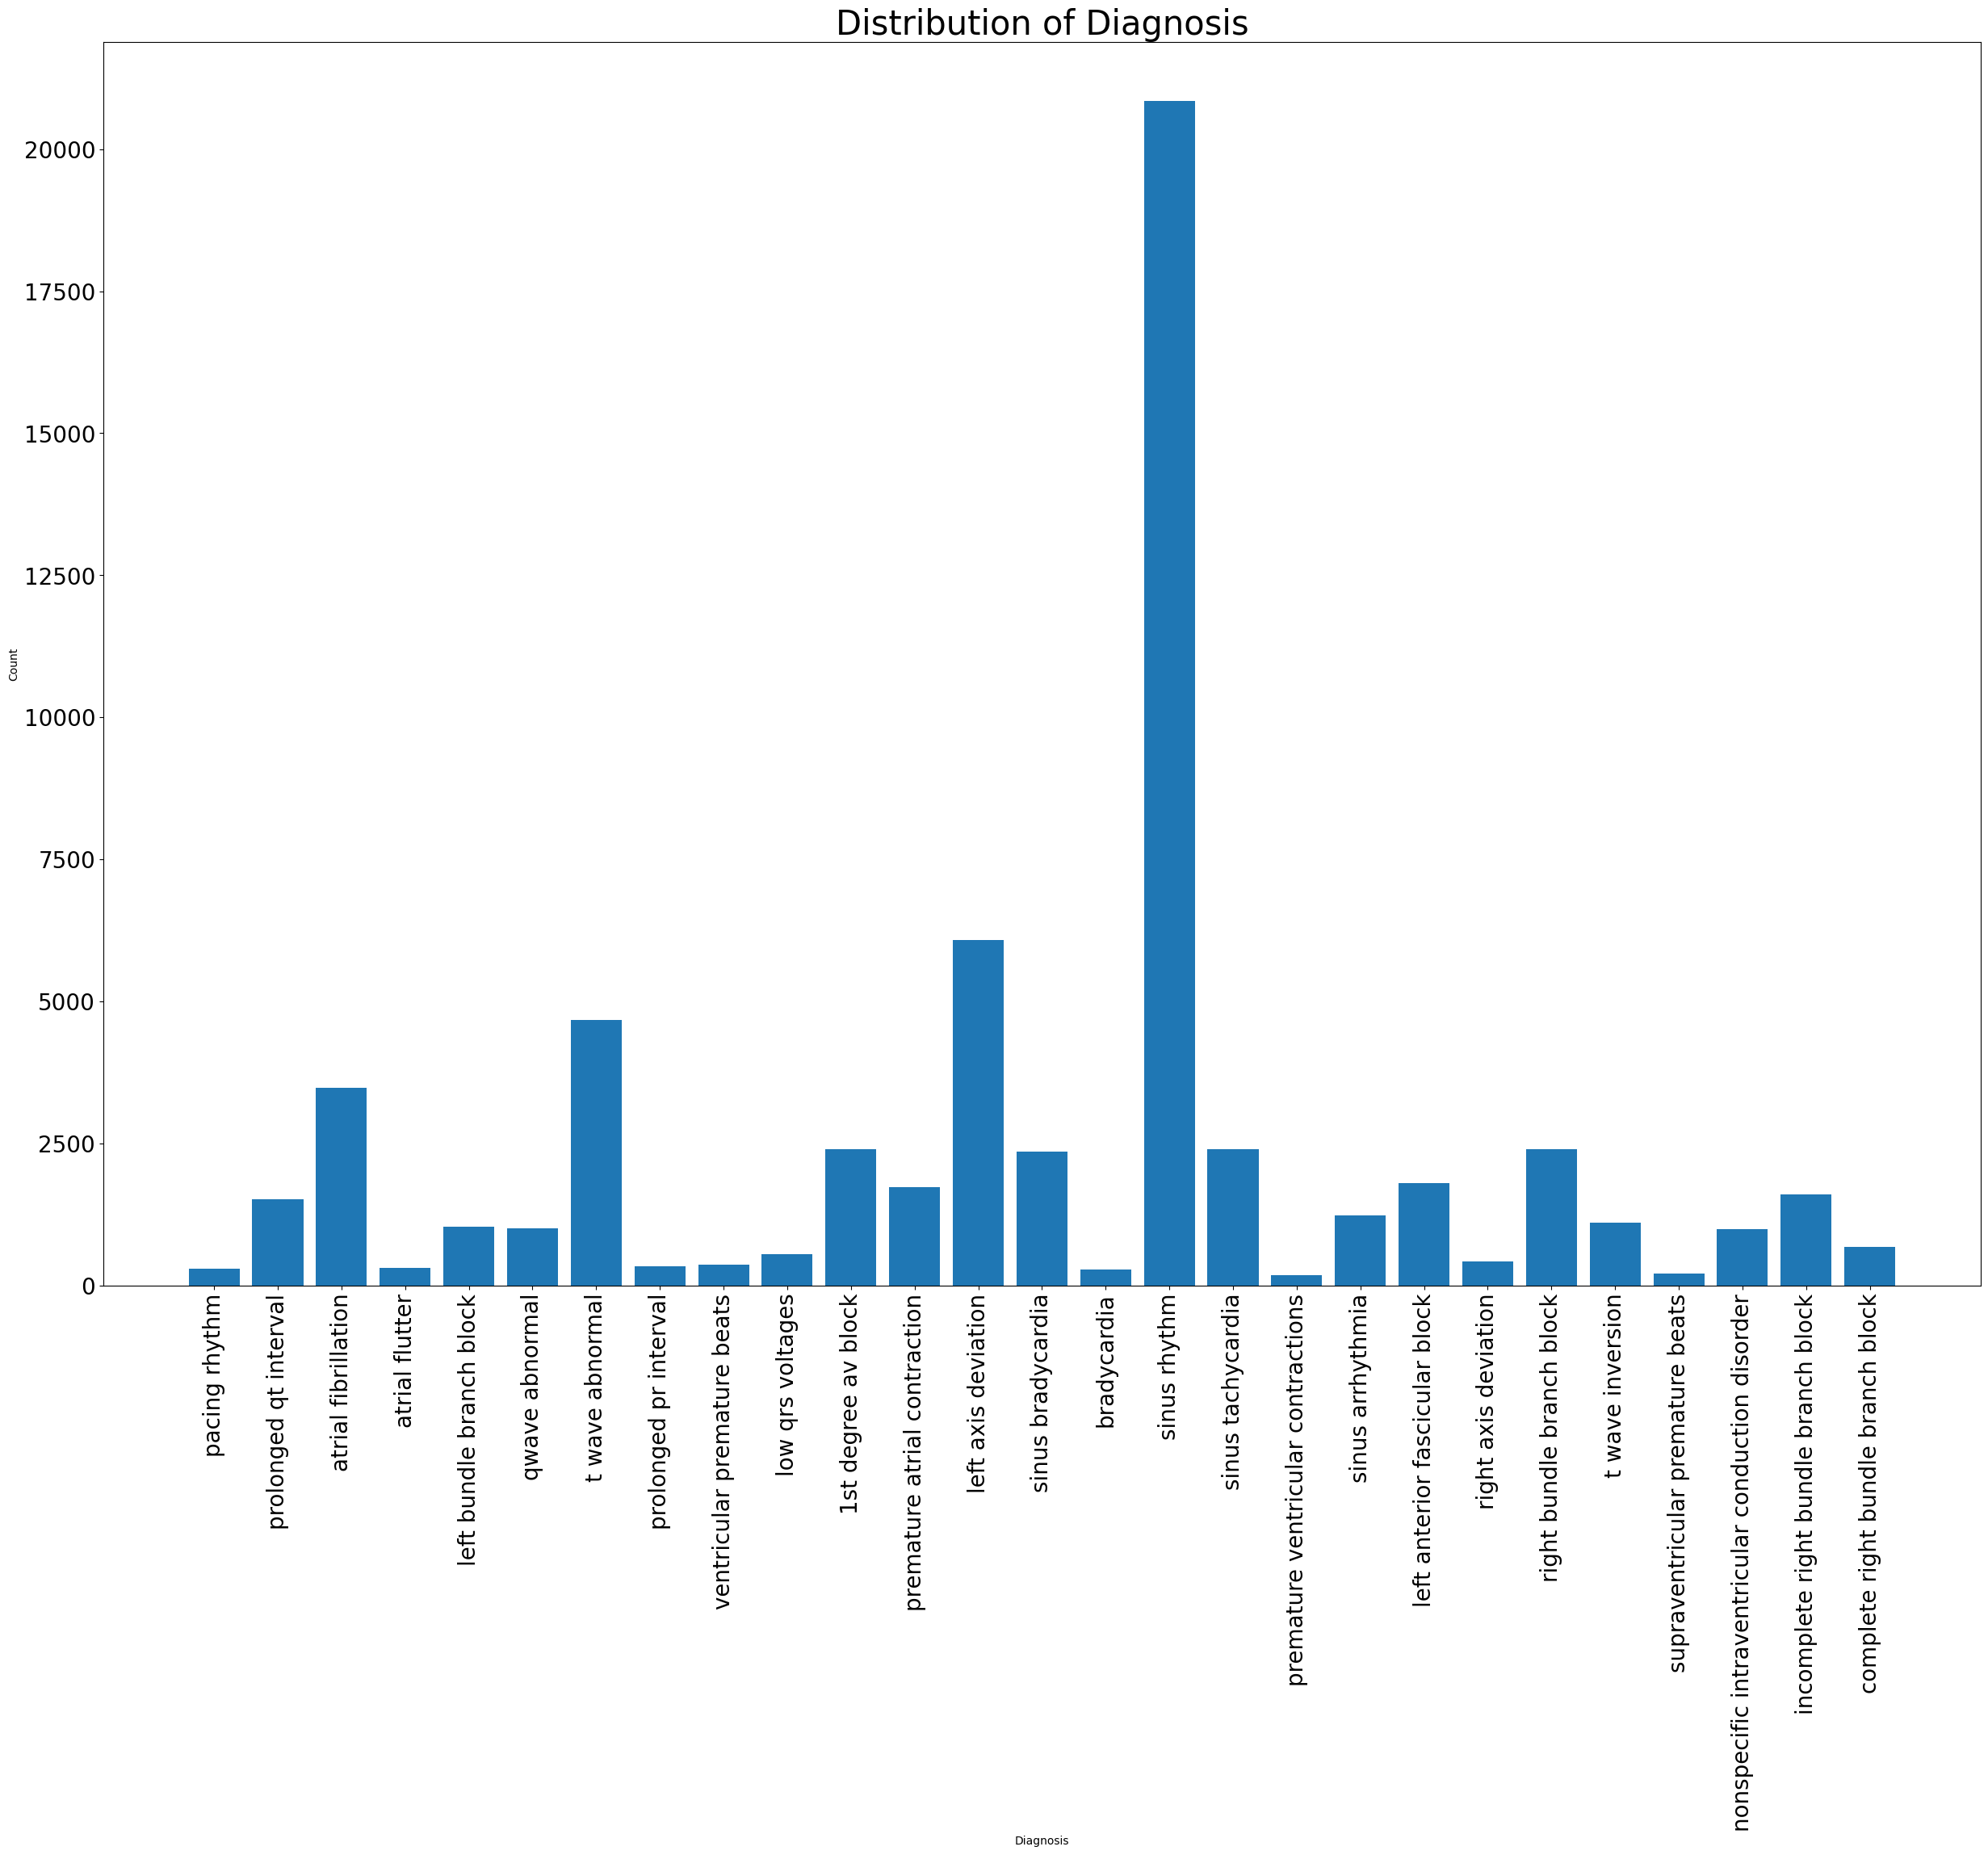

In [28]:
pc.plot_classes(snomed_classes, SNOMED_scored,y)

#### Since this is a multiclass multi-label classification there will be a lot of different combinations of the 27 diagnoses in this study

In [29]:
y_all_comb = pc.get_labels_for_all_combinations(y)
print("Total number of unique combinations of diagnosis: {}".format(len(np.unique(y_all_comb))))

Total number of unique combinations of diagnosis: 1414


#### We will split the data using a 10-fold split with Shuffle=True and random_seed = 42. 
The distribution of Training and Val data in each fold is now:
(in this study we only use the first fold for hold out validation)

In [30]:
folds = pc.split_data(labels, y_all_comb)

Training split: 38790
Validation split: 4311


C:\Users\nares\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(


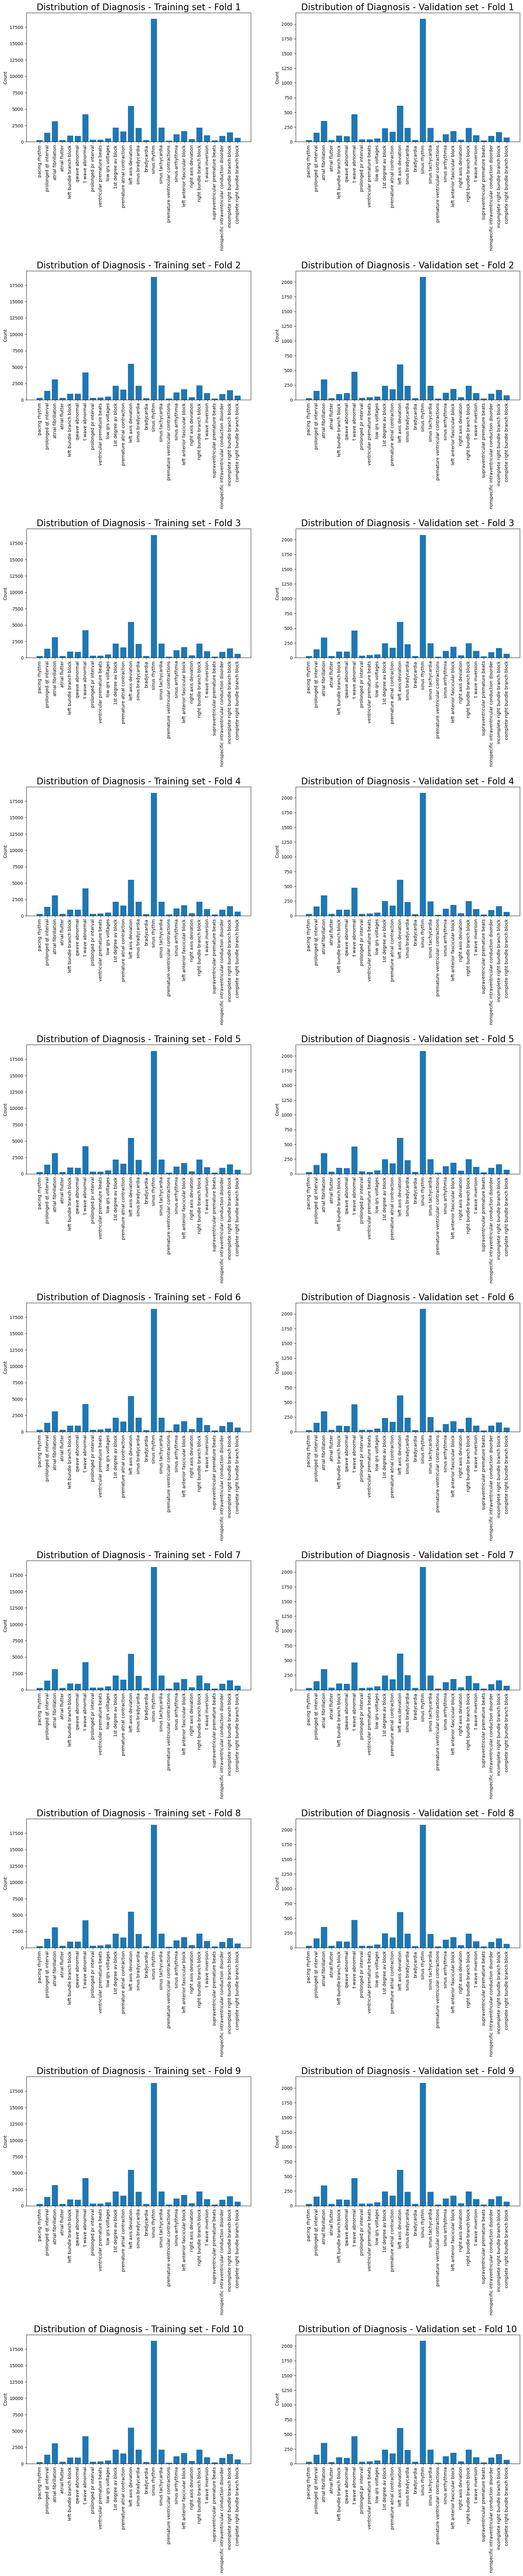

In [31]:
pc.plot_all_folds(folds,y,snomed_classes)

#### Make Batch generators
To feed the Neural Network with a dataset that is too large for our RAM set we need a batch generator to get data into the RAM in batches.
We start by making a "order array" so we can shuffle the order of the data during the training process

In [32]:
order_array = folds[0][0]

In [33]:
def shuffle_batch_generator_demo(batch_size, gen_x,gen_y, gen_z): 
    np.random.shuffle(order_array)
    batch_features = np.zeros((batch_size,5000, 12))
    batch_labels = np.zeros((batch_size,snomed_classes.shape[0])) #drop undef class
    batch_demo_data = np.zeros((batch_size,2))
    while True:
        for i in range(batch_size):

            batch_features[i] = next(gen_x)
            batch_labels[i] = next(gen_y)
            batch_demo_data[i] = next(gen_z)

        X_combined = [batch_features, batch_demo_data]
        yield X_combined, batch_labels
        
def shuffle_batch_generator(batch_size, gen_x,gen_y): 
    np.random.shuffle(order_array)
    batch_features = np.zeros((batch_size,5000, 12))
    batch_labels = np.zeros((batch_size,snomed_classes.shape[0])) #drop undef class
    while True:
        for i in range(batch_size):

            batch_features[i] = next(gen_x)
            batch_labels[i] = next(gen_y)
            
        yield batch_features, batch_labels

def generate_y_shuffle(y_train):
    while True:
        for i in order_array:
            y_shuffled = y_train[i]
            yield y_shuffled


def generate_X_shuffle(X_train):
    while True:
        for i in order_array:
                #if filepath.endswith(".mat"):
                    data, header_data = pc.load_challenge_data(X_train[i])
                    X_train_new = pad_sequences(data, maxlen=5000, truncating='post',padding="post")
                    X_train_new = X_train_new.reshape(5000,12)
                    yield X_train_new

def generate_z_shuffle(age_train, gender_train):
    while True:
        for i in order_array:
            gen_age = age_train[i]
            gen_gender = gender_train[i]
            z_train = [gen_age , gen_gender]
            yield z_train

#### Imbalanced data
To compensate for the imbalaced data we calculate a weight for each label. The weight decides how much the Neural Network will learn from the different data labels

In [34]:
new_weights=pc.calculating_class_weights(y)

In [35]:
keys = np.arange(0,27,1)
weight_dictionary = dict(zip(keys, new_weights.T[1]))
weight_dictionary

{0: 72.0752508361204,
 1: 14.243555849306015,
 2: 6.201582733812949,
 3: 68.63216560509554,
 4: 20.701729106628243,
 5: 21.273938795656466,
 6: 4.611705542478066,
 7: 63.383823529411764,
 8: 59.04246575342466,
 9: 38.759892086330936,
 10: 9.00187969924812,
 11: 12.464141122035858,
 12: 3.5409957279000985,
 13: 9.13543874523103,
 14: 74.828125,
 15: 1.0337954523649622,
 16: 8.971898417985013,
 17: 114.63031914893617,
 18: 17.379435483870967,
 19: 11.932724252491694,
 20: 50.469555035128806,
 21: 8.971898417985013,
 22: 19.379946043165468,
 23: 100.23488372093023,
 24: 21.615346038114343,
 25: 13.37709497206704,
 26: 31.552708638360176}

#### Learning rate reduction
To controll the learning rate we use learning rate reduction and early stopping to prevent overfitting

In [36]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_AUC', factor=0.1, patience=1, verbose=1, mode='max',
    min_delta=0.0001, cooldown=0, min_lr=0
)

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_AUC', mode='max', verbose=1, patience=2)

#### To find the optimal threshold we will use Downhill simplex method

In [37]:
from scipy import optimize
def thr_chall_metrics(thr, label, output_prob):
    return -pc.compute_challenge_metric_for_opt(label, np.array(output_prob>thr))

### Results

#### Residual Neural Network

In [38]:
model = pc.residual_network_1d()

load a pre-trained model

In [39]:
model.load_weights("data/physionet-challenge-models/resnet_model.h5")

##### or train it your self by uncomment the code below

In [ ]:
#batchsize = 30
#model.fit(x=shuffle_batch_generator(batch_size=batchsize, gen_x=generate_X_shuffle(ecg_filenames), gen_y=generate_y_shuffle(y)), epochs=100, steps_per_epoch=(len(order_array)/batchsize), validation_data=pc.generate_validation_data(ecg_filenames,y,folds[0][1]), validation_freq=1, class_weight=weight_dictionary, callbacks=[reduce_lr,early_stop])

In [54]:
ecg_filenames = np.asarray(ecg_filenames, dtype=object)

y_pred = model.predict(x = pc.generate_validation_data(ecg_filenames,y,folds[0][1])[0])

135/135 [==============================] - 97s 716ms/step


In [55]:
init_thresholds = np.arange(0,1,0.05)

In [56]:
all_scores = pc.iterate_threshold(y_pred, ecg_filenames, y ,folds[0][1] )

0.1516625863156977
0.3257728585224567
0.34907885319229215
0.28868950738443655
0.181260365067383
0.07488523992867367
-0.030592151530913974
-0.13422631975369734
-0.2242114341113018
-0.3122581976641526
-0.3953465808086114
-0.47448587178946944
-0.5439621181557601
-0.6015332151710997
-0.6651141368699174
-0.7092221508645785
-0.7470735743049693
-0.7760926050516812
-0.8006819928304572
-0.8173020165059404


In [57]:
new_best_thr = optimize.fmin(thr_chall_metrics, args=(pc.generate_validation_data(ecg_filenames,y,folds[0][1])[1],y_pred), x0=init_thresholds[all_scores.argmax()]*np.ones(27))

Optimization terminated successfully.
         Current function value: -0.380630
         Iterations: 302
         Function evaluations: 579


In [58]:
print(pc.compute_challenge_metric_for_opt(pc.generate_validation_data(ecg_filenames,y,folds[0][1])[1],(y_pred>new_best_thr)*1))

0.38063028434382484


Make conf.matrix

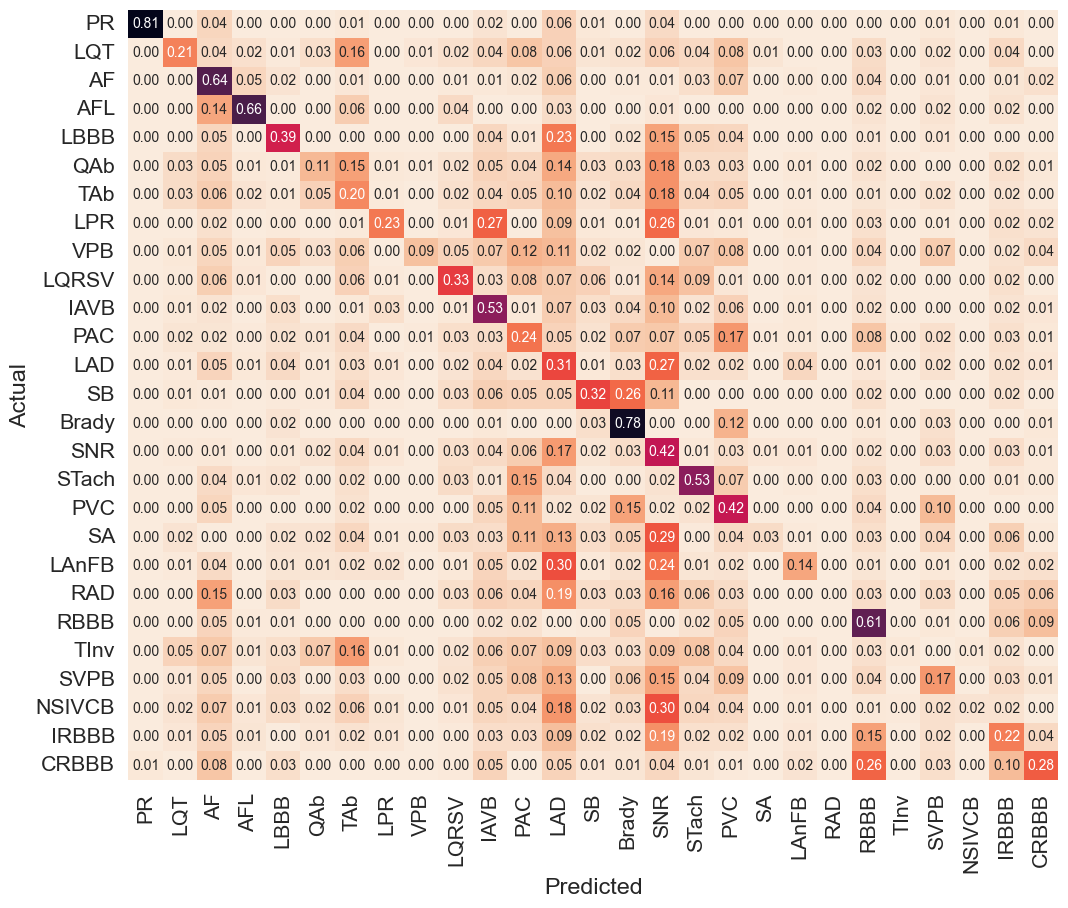

In [59]:
pc.plot_normalized_conf_matrix(y_pred, ecg_filenames, y, folds[0][1], new_best_thr, snomed_classes, snomed_abbr)
plt.savefig("confusion_matrix_resnet.png", dpi=100)

In [60]:
test_aa = pc.generate_validation_data(ecg_filenames,y,folds[0][1])[0]
print(test_aa.shape)

(4311, 5000, 12)


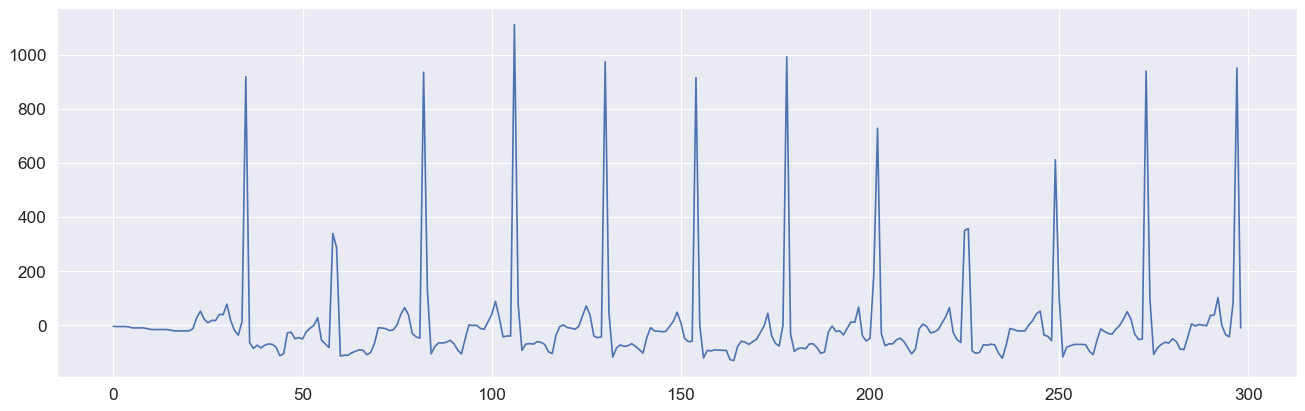

In [63]:
from matplotlib.pyplot import figure

figure(figsize=(20, 6), dpi=80)
plt.plot(test_aa[0,1:300,1])

In [64]:
y_pred.shape

(4311, 27)

In [65]:
test_aa[:2,:,:].shape

(2, 5000, 12)

##TBC

In [72]:
import sys

see_rnn_repo_dir = "see-rnn"

if not os.path.exists(see_rnn_repo_dir):
    !git clone https://github.com/OverLordGoldDragon/see-rnn.git

# add to sys.path so you can import
sys.path.insert(1, see_rnn_repo_dir)

Cloning into 'see-rnn'...


In [100]:
import types, sys
import tensorflow as tf

# Try to get the modern class
try:
    # TF ≥2.4 stable path
    from tensorflow.keras.mixed_precision import LossScaleOptimizer
except Exception:
    try:
        # TF 2.3-era experimental path
        from tensorflow.keras.mixed_precision.experimental import LossScaleOptimizer  # type: ignore
    except Exception:
        LossScaleOptimizer = None  # fallback

# Create a shim so see-rnn's old import succeeds
if LossScaleOptimizer is not None:
    mod = types.ModuleType("tensorflow.python.keras.mixed_precision.experimental")
    class _LSO:  # acts like the old module object
        LossScaleOptimizer = LossScaleOptimizer
    mod.loss_scale_optimizer = _LSO
    sys.modules["tensorflow.python.keras.mixed_precision.experimental"] = mod

# now import see_rnn
from see_rnn import get_gradients, get_outputs, features_0D, features_1D, features_2D


In [90]:
import sys, types
import tensorflow as tf

# --- 1) Shim old mixed-precision import path (if you haven't already) ---
try:
    from tensorflow.keras.mixed_precision import LossScaleOptimizer
except Exception:
    try:
        from tensorflow.keras.mixed_precision.experimental import LossScaleOptimizer  # type: ignore
    except Exception:
        class LossScaleOptimizer:  # harmless stub
            pass

mod = types.ModuleType("tensorflow.python.keras.mixed_precision.experimental")
class _LSO: pass
_LSO.LossScaleOptimizer = LossScaleOptimizer
mod.loss_scale_optimizer = _LSO
sys.modules["tensorflow.python.keras.mixed_precision.experimental"] = mod

# --- 2) Ensure optimizer has the legacy flag used by see-rnn ---
if hasattr(model, "optimizer") and not hasattr(model.optimizer, "_HAS_AGGREGATE_GRAD"):
    # False works fine for modern single-replica strategies
    model.optimizer._HAS_AGGREGATE_GRAD = False


(2, 5000, 64)


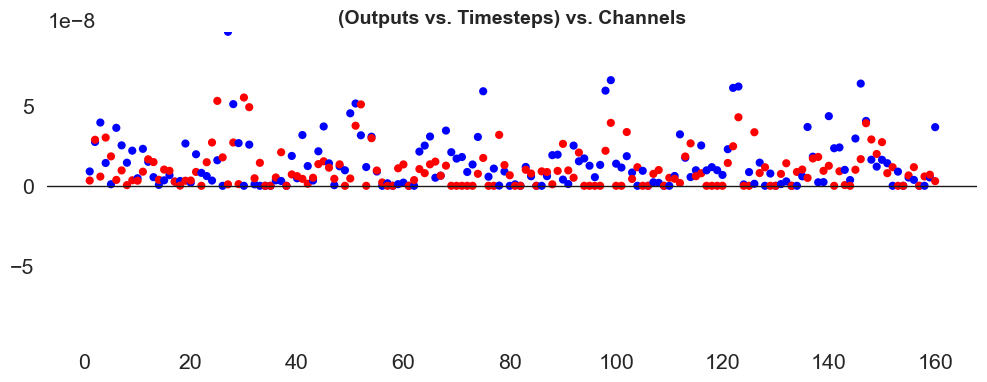

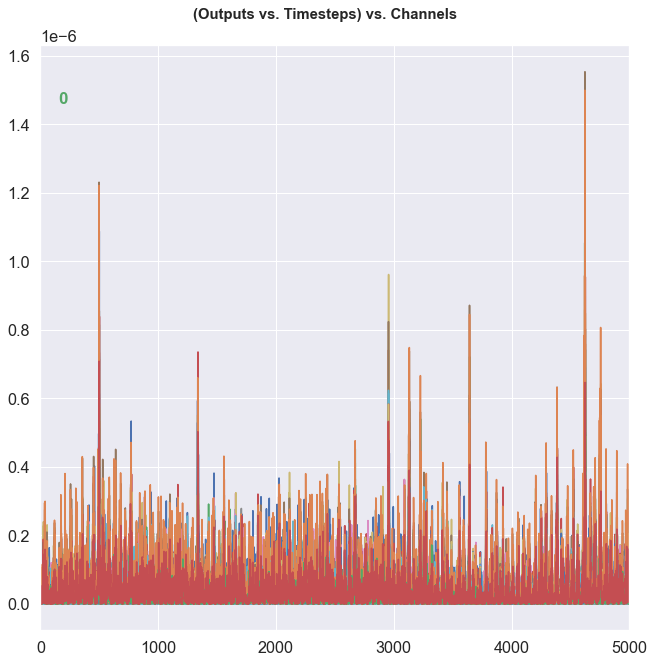

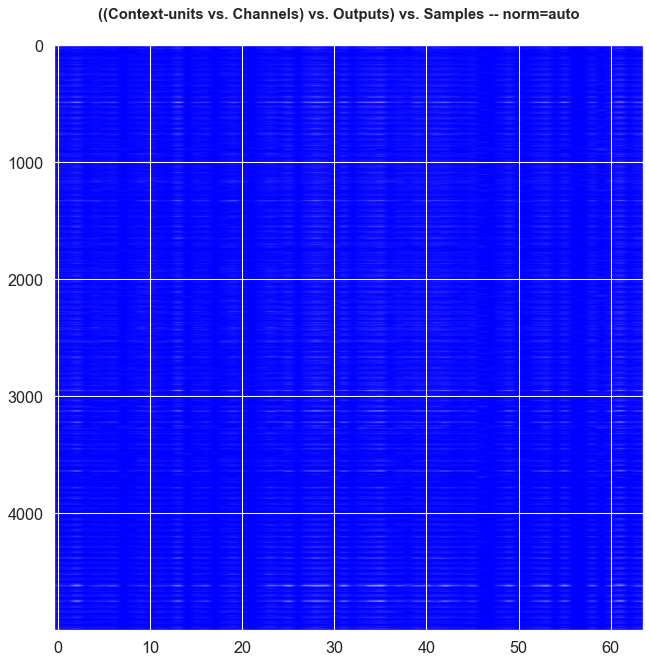

(<Figure size 760x760 with 1 Axes>, array(<Axes: >, dtype=object))

In [135]:
import tensorflow as tf
import numpy as np

lidx = 1  # the layer you care about
feat_model = tf.keras.Model(model.inputs, [model.layers[lidx].output, model.output])

x = test_aa[:2, :, :]
y_true = y[:2, :]

with tf.GradientTape() as tape:
    activ, y_hat = feat_model(x, training=False)
    loss_fn = tf.keras.losses.get(model.loss) if hasattr(model, "loss") else tf.keras.losses.CategoricalCrossentropy()
    loss = loss_fn(y_true, y_hat)

grads_all = tape.gradient(loss, activ).numpy()  # shape: (batch, time, features) for recurrent/conv temporal layers

grads_last = grads_all[:, -1, :]   # last timestep slice


print(grads_all.shape)

features_0D(np.abs(grads_all[0,0:160,:2]))               # (features,) -> 0D OK
features_1D(np.abs(grads_all[1]), n_rows=4)               # (time, features) -> 2D OK
features_2D(np.abs(grads_all[1]))               # (time, features) -> 2D OK


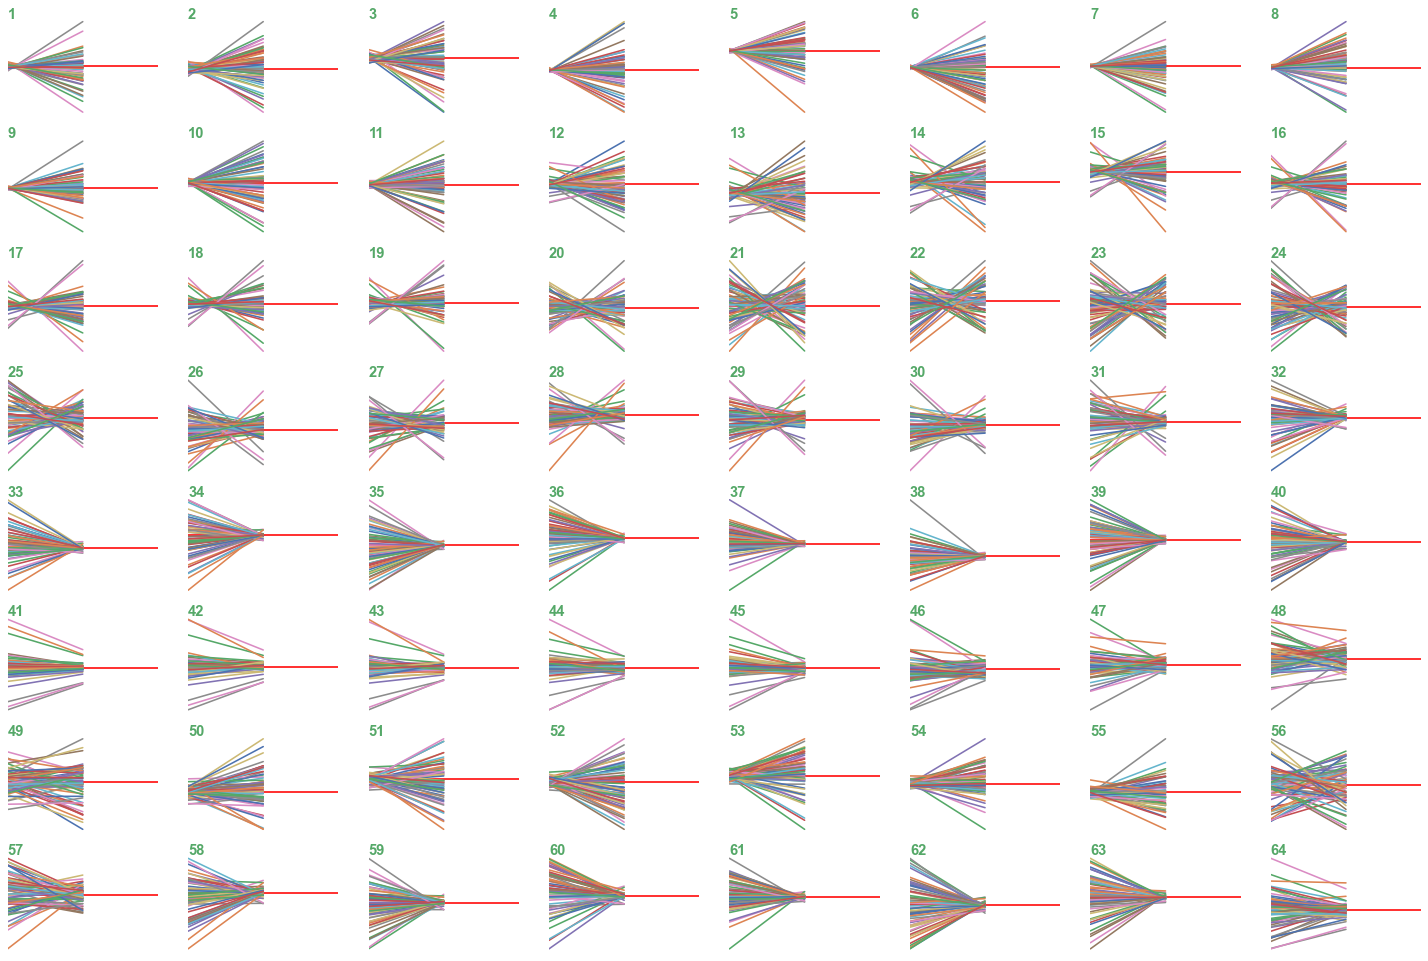

In [124]:
# https://stackoverflow.com/questions/58356868/how-visualize-attention-lstm-using-keras-self-attention-package
def show_features_1D_nv(model=None, layer_name=None, input_data=None,
                     prefetched_outputs=None, max_timesteps=100,
                     max_col_subplots=10, equate_axes=False,
                     show_y_zero=True, channel_axis=-1,
                     scale_width=1, scale_height=1, dpi=76):
    if prefetched_outputs is None:
        layer_outputs = get_layer_outputs(model, layer_name, input_data, 1)[0]
    else:
        layer_outputs = prefetched_outputs
    n_features    = layer_outputs.shape[channel_axis]

    for _int in range(1, max_col_subplots+1):
          if (n_features/_int).is_integer():
                n_cols = int(n_features/_int)
    n_rows = int(n_features/n_cols)

    fig, axes = plt.subplots(n_rows,n_cols,sharey=equate_axes,dpi=dpi)
    fig.set_size_inches(24*scale_width,16*scale_height)

    subplot_idx = 0
    for row_idx in range(axes.shape[0]):
        for col_idx in range(axes.shape[1]): 
            subplot_idx += 1
            feature_output = layer_outputs[:,subplot_idx-1]
            feature_output = feature_output[:max_timesteps]
            ax = axes[row_idx,col_idx]

            if show_y_zero:
                ax.axhline(0,color='red')
            ax.plot(feature_output)

            ax.axis(xmin=0,xmax=len(feature_output))
            ax.axis('off')

            ax.annotate(str(subplot_idx),xy=(0,.99),xycoords='axes fraction',
                        weight='bold',fontsize=14,color='g')
    if equate_axes:
        y_new = []
        for row_axis in axes:
            y_new += [np.max(np.abs([col_axis.get_ylim() for 
                                        col_axis in row_axis]))]
        y_new = np.max(y_new)
        for row_axis in axes:
            [col_axis.set_ylim(-y_new,y_new) for col_axis in row_axis]
    plt.show()

show_features_1D_nv(grads_all, prefetched_outputs = outs)

(2, 5000, 64)


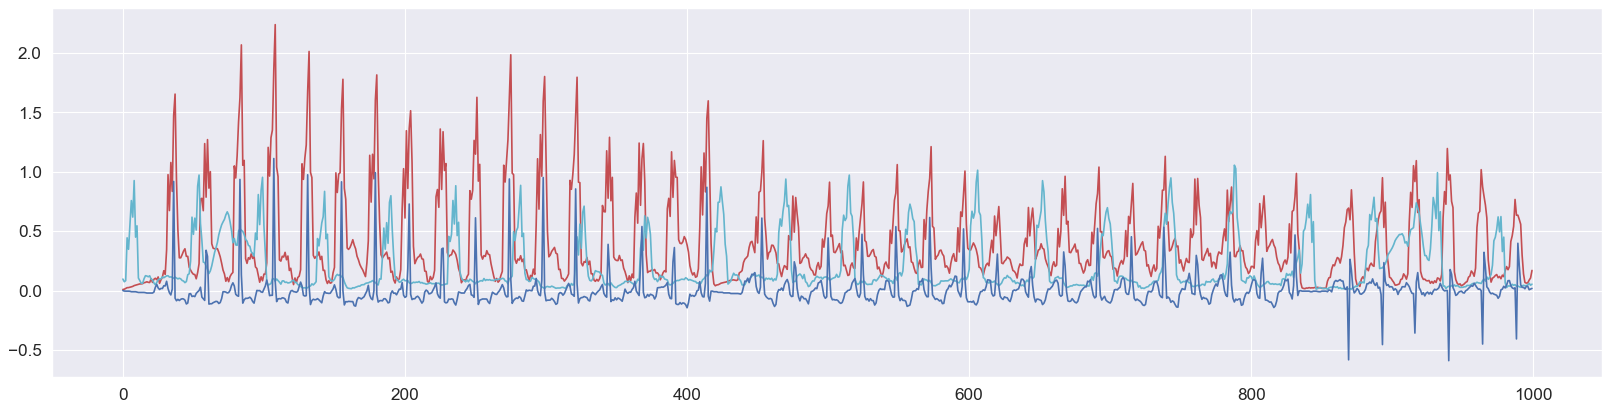

In [118]:
print(grads_all.shape)
end_time = 1000
figure(figsize=(25, 6), dpi=80)
# plt.plot(test_aa[0,1:1000,1]/1000)
plt.plot(pd.DataFrame(outs[0]).max(axis= 1).values[:end_time]/2000,'r')
plt.plot(pd.DataFrame(outs[1]).max(axis= 1).values[:end_time]/2000,'c')
plt.plot(test_aa[0,:end_time,1]/1000)
plt.show()

In [119]:
grads_all.shape

(2, 5000, 64)

In [138]:
end_time = int(5000/28)
thresh = 0.2
x_range = range(end_time)
# gradient_1 = pd.DataFrame(grads_all[0,:,:]).abs().max(axis= 1).values[:end_time]*10**13
gradient_1 = pd.DataFrame(grads_last[0,:,:]).abs().max(axis= 1).values[:end_time]*10**10
gradient_12 = []
for ii in range(end_time):
    if gradient_1[ii] >= thresh:
           gradient_12.append(test_aa[0,ii,1])
    else:
        gradient_12.append(0)

figure(figsize=(25, 6), dpi=80)
# plt.plot(test_aa[0,1:1000,1]/1000)
# plt.plot(gradient_12,'r',linewidth=5.0)
# plt.plot(np.array(np.where(gradient_1 >=0.2)).reshape(-1,1), gradient_1[np.where(gradient_1 >= 0.2)],'r',linewidth=5.0)
# plt.scatter(np.array(np.where(gradient_1 >=thresh)).reshape(-1,1), gradient_1[np.where(gradient_1 >= thresh)], c='r')
plt.scatter(np.array(np.where(gradient_1 >=thresh)).reshape(-1,1), pd.DataFrame(gradient_12).iloc[np.where(gradient_1 >= thresh)], c='r')
plt.plot(test_aa[0,:end_time,1],linewidth=3)
plt.show()

IndexError: too many indices for array: array is 2-dimensional, but 3 were indexed

In [137]:
pd.DataFrame(grads_all[0,:,:]).abs().max(axis= 1).values[:end_time]*10**13

array([ 722618.2674458 ,  769465.41582856,  721667.27704825,
        798214.40124306, 1022569.97536188,  922427.14799795,
        697144.17350042,  819189.26753133,  670178.36613559,
        621604.3857421 ,  667139.09063765,  543990.91453661,
        543007.06153754,  311198.88888043,  278657.29279597,
        371338.65760097,  340897.94098691,  375865.77406046,
        417468.12229349,  455056.47250366,  338678.84496885,
        489317.52871795,  386849.87657689,  629353.5648183 ,
        727026.75879555,  837946.03256138, 1669741.18087637,
       2481489.78698737, 1302419.86084911, 1042652.68419113,
       1269554.41714927,  609417.86728108,  243539.99705795,
        207051.03409568,  191022.93080664,  223217.81756318,
        212086.06426626,  199515.56851083,  291468.34279459,
        348436.40861482,  421491.78369755,  354138.9048678 ,
        630935.73032802,  644319.86857016, 1322101.04197839,
       1058290.16661119,  781712.68569349,  857863.46915029,
       1007675.5074806 ,

In [142]:
ecg_data = pc.load_challenge_data(ecg_filenames[0])
ecg_data2 = np.array(ecg_data)

end_time = 5000
thresh = 1.2
x_range = range(end_time)
gradient_1 = pd.DataFrame(grads_all[0,:,:]).abs().max(axis= 1).values[:end_time]*10**13
gradient_12 = []
for ii in range(end_time):
    if gradient_1[ii] >= thresh:
           gradient_12.append(ecg_data2[0][0,ii]/1000)
    else:
        gradient_12.append(0)

fig, ax = plt.subplots(figsize=(25, 6), dpi=200)

fig.suptitle(snomed_classes[np.argmax(y_pred[0])])

ax.scatter(np.array(np.where(gradient_1 >=thresh)).reshape(-1,1), pd.DataFrame(gradient_12).iloc[np.where(gradient_1 >= thresh)], c='r', s = 200, alpha= 0.7)
step = 1.0/500
# plt.scatter(np.arange(0, len(np.array(np.where(gradient_1 >=thresh)).reshape(-1,1))*step, step), pd.DataFrame(gradient_12).iloc[np.where(gradient_1 >= thresh)], c='r')
plt.plot(ecg_data2[0][0, :end_time]/1000,linewidth=3)

# ax.plot(np.arange(0, len(ecg_data2[0][0, :end_time])*step, step), ecg_data2[0][0, :end_time],  linewidth=2.0, color='b')
plt.show()

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

In [143]:
print(ecg_data2[0].shape)
ecg_plot.plot(ecg_data2[0]/1000, sample_rate=500, title='')
ecg_plot.show()

AttributeError: 'str' object has no attribute 'shape'

In [144]:
sample = np.array(test_aa[0:10]).copy()
sample.shape

(10, 5000, 12)

## Class implementation

In [145]:
import itertools
import numpy as np
import sklearn
from sklearn.linear_model import LinearRegression

class Telmi:
    def __init__(self,model,data,num_perturbations: int,window_size:int, kernel_width=0.25):
        self.model = model
        self.data = data
        self.num_perturbations = num_perturbations
        self.window_size = window_size
        self.kernel_width = kernel_width
        self.num_features = data.shape[2]
        if len(data.shape) != 3:
            raise ValueError("input Data must be batch of instance")

    def _kernel_func(self, distances):
        return np.sqrt(np.exp(-(distances ** 2) / self.kernel_width ** 2))

    def _instance_feature_explain(self, instance):
        instance = np.array([instance])
        top_class = model.predict(instance)[0].argsort()
        perturbations_sets = self._create_perturbations_sets(self.num_perturbations,self.num_features)
        perturb_instance_predictions = np.array([model.predict(subset * instance) for subset in perturbations_sets])
        original_instance = np.ones(self.num_features)[np.newaxis,:]
        distances = sklearn.metrics.pairwise_distances(perturbations_sets,original_instance, metric='cosine').ravel()
        weights = self._kernel_func(distances)
        surrogate_model = LinearRegression()
        surrogate_model.fit(perturbations_sets, perturb_instance_predictions[:,:,top_class[-1]], sample_weight=weights)
        return surrogate_model.coef_[0]
    
    def _instance_event_explain(self, instance):
        instance = np.array([instance])
        top_class = model.predict(instance)[0].argsort()
        num_events = int(np.ceil(instance.shape[1] / self.window_size))
        events = list(self._create_event_chunks(instance[0].copy(),num_events))
        perturbations_sets = self._create_perturbations_sets(self.num_perturbations,num_events)
        perturb_events_predictions = []
        for subset in perturbations_sets:
            perturb_events = np.array(list(map(lambda x:x[0] * x[1], zip(events,subset))))
            perturb_events_predictions.append(model.predict(perturb_events))
        perturb_events_predictions = np.array(perturb_events_predictions)
        original_instance = np.ones(num_events)[np.newaxis,:]
        distances = sklearn.metrics.pairwise_distances(perturbations_sets,original_instance, metric='cosine').ravel()
        weights = self._kernel_func(distances)
        surrogate_model = LinearRegression()
        surrogate_model.fit(perturbations_sets, perturb_events_predictions[:,:,top_class[-1]], sample_weight=weights)
        return surrogate_model.coef_[0]

    def feature_explain(self):
        return np.array(list(map(self._instance_feature_explain,self.data)))
    
    def event_explain(self):
        return np.array(list(map(self._instance_event_explain,self.data)))
    
    @staticmethod
    def _create_perturbations_sets(m: int, n: int):
        perturbations_sets = list(map(list, itertools.product([0, 1], repeat=n)))
        if m==-1 or m==2**n:
            return np.array(perturbations_sets)
        random_index = np.random.choice(len(perturbations_sets), m, replace=False)
        random_perturbations_sets = [perturbations_sets[i] for i in random_index]
        return np.array(random_perturbations_sets)


    @staticmethod
    def _create_event_chunks(instance, num_chunks: int):
        for i in range(0, len(instance), num_chunks):
            yield instance[i:i+num_chunks]   


In [146]:
x = Telmi(model,sample,200,500)

In [147]:
x.feature_explain()

1/1 [==============================] - 0s 47ms/step


array([[ 2.56185191e-02,  9.64615383e-02,  5.41890424e-02,
         4.94499876e-02,  8.92991657e-02,  3.13708759e-02,
         5.47208577e-03, -6.29704823e-02,  1.41112540e-01,
         4.80989554e-02,  2.21743173e-02,  3.59408266e-02],
       [-3.50622852e-03, -4.70676507e-03, -1.01484145e-02,
         4.65036711e-03,  2.59599876e-03,  5.99768608e-03,
        -3.29796527e-03,  1.90893058e-03, -3.33558225e-03,
         7.32074909e-03,  7.95110355e-03, -4.13252961e-04],
       [-1.11406107e-02, -9.27336554e-03,  1.06844648e-02,
         1.89239989e-02,  1.09479880e-02,  2.22518419e-02,
         6.89694225e-03,  1.31430902e-02, -7.52078252e-03,
         2.09783617e-02,  2.47067985e-03, -5.86412094e-03],
       [-7.29819851e-04, -1.08668472e-03, -1.50318607e-03,
         8.05579428e-04, -7.68424160e-04,  6.79064109e-04,
        -7.90823521e-04,  8.48912917e-04, -1.09349878e-03,
         1.31522429e-03,  7.18088390e-04,  1.19644108e-04],
       [-1.79408385e-02,  5.74035809e-02,  1.0661893

In [98]:
x.event_explain()

1/1 [==============================] - 0s 22ms/step


array([[-8.13917504e-05, -1.24571575e-21, -3.89010286e-20,
        -2.21990892e-20, -1.00260266e-20,  1.25238820e-20,
        -2.54870152e-25, -4.73528731e-21, -1.32739348e-20,
         3.97100523e-20],
       [-2.13852551e-01, -7.46863698e-18,  1.07848857e-16,
        -2.08259324e-16,  2.09934611e-18, -1.62070615e-16,
         1.26210180e-16, -1.43538012e-17, -8.67746795e-17,
        -3.80285579e-17],
       [ 3.54288518e-03, -3.01129038e-19, -5.55331123e-19,
         9.98253729e-19,  1.33165283e-19,  8.71946861e-19,
         8.83268317e-19, -1.80529178e-19, -2.60589667e-19,
        -3.34602211e-19],
       [ 7.75011750e-02,  1.28267206e-17, -1.20051577e-18,
        -2.73811783e-17, -3.01171330e-17,  2.72352273e-17,
         7.15551387e-18,  4.92487748e-18,  1.31669759e-17,
        -3.24634447e-17],
       [ 4.40487154e-02, -5.70281847e-20, -1.25265031e-18,
        -6.55347036e-18,  3.25000883e-18,  1.02175157e-19,
        -8.45444862e-18,  6.56008814e-18,  2.73072280e-18,
         4.

## Feature explain

In [149]:
import sklearn
from sklearn.linear_model import LinearRegression

In [150]:
sample_prediction = model.predict(sample)

1/1 [==============================] - 0s 225ms/step


In [151]:
top_classes = sample_prediction[0].argsort()

In [152]:
top_classes

array([13,  7,  0,  9, 26, 10, 19,  3,  4, 20,  2, 12, 18, 14, 25, 21, 15,
        1, 24, 23,  8, 22,  6,  5, 17, 11, 16], dtype=int64)

In [153]:
num_perturbations = 200
num_feature = 12
perturbations = np.random.binomial(1, 0.5, size=(num_perturbations, num_feature))
perturbations

array([[1, 0, 0, ..., 1, 1, 1],
       [0, 0, 1, ..., 1, 0, 0],
       [1, 1, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 1, 0, 1],
       [1, 0, 0, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 0, 1]])

In [154]:
perturb_prediction = []
distance = []
for subset in perturbations:
    data = sample * subset
    perturb_prediction.append(model.predict(data))
perturb_prediction = np.array(perturb_prediction)

1/1 [==============================] - 0s 237ms/step


In [155]:
perturb_prediction.shape


(200, 10, 27)

In [156]:
original_instance = np.ones(num_feature)[np.newaxis,:]
distances = sklearn.metrics.pairwise_distances(perturbations,original_instance, metric='cosine').ravel()
distances.shape

(200,)

In [157]:
kernel_width = 0.25
weights = np.sqrt(np.exp(-(distances**2)/kernel_width**2))
weights.shape

(200,)

In [158]:
class_to_explain = top_classes[-1]
surrogate_model = LinearRegression()
surrogate_model.fit(X=perturbations, y=perturb_prediction[:,:,class_to_explain], sample_weight=weights)
coeff = surrogate_model.coef_[0]
coeff

array([0.0519161 , 0.0860737 , 0.06746487, 0.00201657, 0.00219357,
       0.08732274, 0.01777023, 0.04203458, 0.08974128, 0.04229569,
       0.00777228, 0.05087875])

In [159]:
%pip install plotly
%pip install --upgrade nbformat

import plotly.express as px


Coeff_df = pd.DataFrame()

Coeff_df['TELMI'] = coeff

fig = px.bar(Coeff_df, x=Coeff_df['TELMI'], y= Coeff_df.index, orientation='h', color=Coeff_df.index)
fig.show()

Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


In [160]:
import plotly.graph_objects as go

fig = go.Figure(go.Waterfall(
    name = "20", 
    orientation = "h",
    x = Coeff_df['TELMI'],
    textposition = "outside",
    y = Coeff_df['TELMI'].index,    
    connector = {"line":{"color":"rgb(63, 63, 63)"}},
))

fig.update_layout(
        title = "TELMI Explanability",
        showlegend = True
)

fig.show()

## event explain

In [161]:
sample = np.array([test_aa[0]])

In [162]:
num_perturbations = 200
num_feature = 10
perturbations = np.random.binomial(1, 0.5, size=(num_perturbations, num_feature))
perturbations

array([[0, 1, 1, ..., 0, 0, 0],
       [1, 1, 0, ..., 1, 0, 1],
       [1, 1, 1, ..., 1, 0, 0],
       ...,
       [1, 1, 0, ..., 0, 0, 1],
       [0, 1, 0, ..., 1, 1, 0],
       [0, 1, 0, ..., 0, 1, 1]])

In [163]:
reshaped_sample = sample.reshape((5000,12)).copy()

In [164]:
perturb_prediction = []
distance = []
for subset in perturbations:
    reshaped_sample = sample.reshape((5000,12)).copy()
    splited_event = np.array_split(reshaped_sample,10)
    for idx, value in enumerate(subset):
        if value == 0:
            splited_event[idx][:,:] = 0
    perturb_prediction.append(model.predict(np.array(splited_event)))
perturb_prediction = np.array(perturb_prediction)

1/1 [==============================] - 0s 49ms/step


In [165]:
original_instance = np.ones(num_feature)[np.newaxis,:]
distances = sklearn.metrics.pairwise_distances(perturbations,original_instance, metric='cosine').ravel()
distances.shape

(200,)

In [166]:
kernel_width = 0.25
weights = np.sqrt(np.exp(-(distances**2)/kernel_width**2))
weights.shape

(200,)

In [167]:
class_to_explain = top_classes[-1]
surrogate_model = LinearRegression()
surrogate_model.fit(X=perturbations, y=perturb_prediction[:,:,class_to_explain], sample_weight=weights)
coeff = surrogate_model.coef_[0]
coeff

array([ 1.63374348e-01,  8.79411742e-17, -1.23621933e-16, -1.11813865e-16,
        1.67188435e-17, -5.46629750e-17,  1.76672172e-16, -1.99657402e-17,
       -8.21463952e-17,  7.85715960e-18])

In [168]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

def prepare_ecg(filepath, maxlen=5000):
    data, header = pc.load_challenge_data(filepath)  # shape: (12, variable_length)
    data = np.array(data).T  # shape: (length, 12)
    data = pad_sequences([data], maxlen=maxlen, padding='post', truncating='post', dtype='float32')  # shape: (1, maxlen, 12)
    return data

C:\Users\nares\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\shap\explainers\_deep\deep_tf.py:94: UserWarning:

Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.

C:\Users\nares\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\backend.py:452: UserWarning:

`tf.keras.backend.set_learning_phase` is deprecated and will be removed after 2020-10-11. To update it, simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.



IndexError: index 20 is out of bounds for axis 1 with size 12

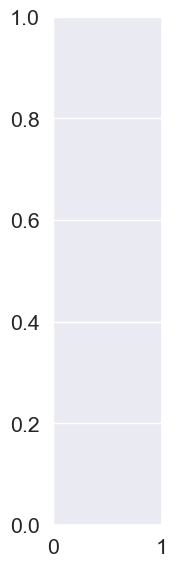

In [172]:
import shap

ecg_file = "data/china-12lead-ecg-challenge-database/Training_2/Q0002.mat"
sample_input = prepare_ecg(ecg_file)  # shape: (1, 5000, 12)
background = np.vstack([prepare_ecg(f) for f in ecg_filenames[:100]])  # shape: (100, 5000, 12)

explainer = shap.DeepExplainer(model, background)
shap_values = explainer.shap_values(sample_input)

shap.summary_plot(shap_values[0], sample_input[0], feature_names=[f"Lead_{i}" for i in range(sample_input.shape[2])])


Text(0.5, 1.0, 'Grad-CAM (1D) Heatmap')

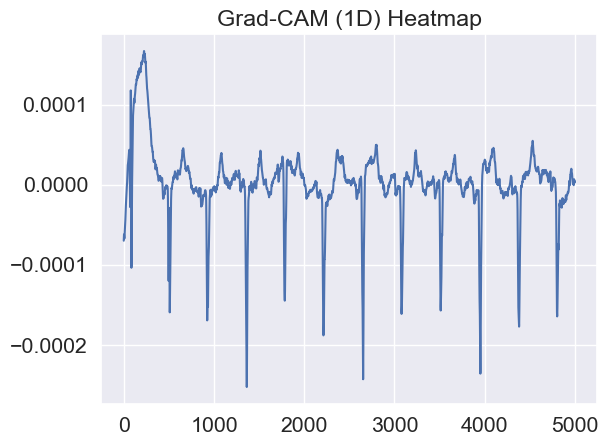

In [174]:
import tensorflow as tf
import matplotlib.pyplot as plt

def grad_cam_1d(model, input_data, layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        inputs = tf.cast(input_data, tf.float32)
        conv_outputs, predictions = grad_model(inputs)
        loss = predictions[:, tf.argmax(predictions[0])]
    grads = tape.gradient(loss, conv_outputs)
    weights = tf.reduce_mean(grads, axis=1)
    cam = tf.reduce_sum(tf.multiply(weights[:, tf.newaxis, :], conv_outputs), axis=-1)
    return cam.numpy()

# Usage
sample_input = prepare_ecg("data/china-12lead-ecg-challenge-database/Training_2/Q0002.mat")
cam = grad_cam_1d(model, sample_input, layer_name='conv1d_3')  # replace with actual layer name
plt.plot(cam[0])
plt.title("Grad-CAM (1D) Heatmap")


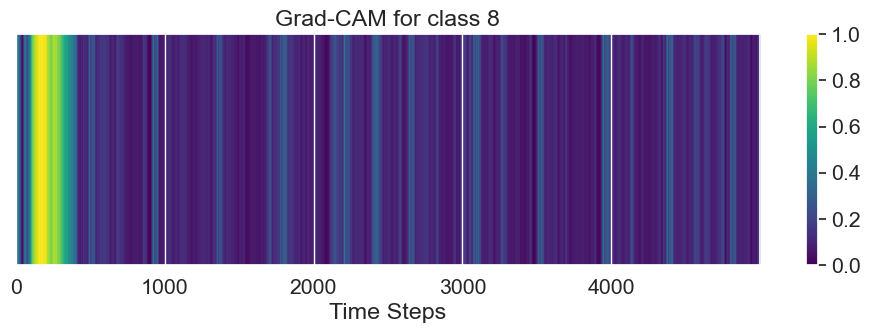

In [176]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# build model to output last conv layer + predictions
last_conv = model.get_layer('conv1d_10')
grad_model = tf.keras.Model([model.inputs],
                            [last_conv.output, model.output])

# forward + backward pass
with tf.GradientTape() as tape:
    conv_out, preds = grad_model(sample_input)
    class_idx = tf.argmax(preds[0])
    loss = preds[:, class_idx]

# compute gradients wrt conv features
grads = tape.gradient(loss, conv_out)
weights = tf.reduce_mean(grads, axis=1)   # average over time axis
cam = tf.reduce_sum(tf.multiply(weights, conv_out), axis=-1)

# normalize CAM
cam = cam[0].numpy()
cam = (cam - cam.min()) / (cam.max() - cam.min())

# plot heatmap
plt.figure(figsize=(12, 3))
plt.imshow(cam[np.newaxis, :], aspect="auto", cmap="viridis")
plt.title(f"Grad-CAM for class {class_idx.numpy()}")
plt.xlabel("Time Steps")
plt.yticks([])
plt.colorbar()
plt.show()
